### Import Dependecies

In [1]:
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add
from openai import OpenAI
import openai

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message

from langsmith import traceable

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import Filter, FieldCondition, MatchValue, VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

### Agent Graph with Loopback from Tools (ReAct Agent)

### Define Retirieval Tool

In [2]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model_name": "text-embedding-3-small"}
)
def get_embedding(text, model="text-embedding-3-small"):    
    response = openai.embeddings.create(
        input=text,
        model=model,
    )

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5):

    query_embedding = get_embedding(query)

    qdrant_client = QdrantClient(url="http://localhost:6333")

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1,1])),
        limit=k
    )

    retrieved_context_ids = []
    retieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }


@traceable(
    name="format_retrieved_context",
    run_type="prompt"
)
def process_context(context):

    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context


def get_formatted_item_context(query: str, top_k: int = 5) -> str:

    """Get the top k context, each representing an inventory item for a given query.
    
    Args:
        query: The query to get the top k context for
        top_k: The number of context chunks to retrieve, works best with 5 or more
    
    Returns:
        A string of the top k context chunks with IDs and average ratings prepending each chunk, each representing an inventory item for a given query.
    """

    context = retrieve_data(query, top_k)
    formatted_context = process_context(context)

    return formatted_context

### State and Pydantic Models for Structured Outputs

In [3]:
class ToolCall(BaseModel):
    name: str
    arguments: dict

class RAGUsedContext(BaseModel):
    id: str = Field(description="ID of the item used to answer the question")
    description: str = Field(description="Short description of the item used to answer the question")

class AgentResponse(BaseModel):
    answer: str
    references: list[RAGUsedContext] = Field(description="List of items used to answer the question")
    final_answer: bool = False
    tool_calls: List[ToolCall] = []

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    message: str = ""
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []
    final_answer: bool = False
    references: Annotated[List[RAGUsedContext], add] = []

In [4]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def agent_node(state: State) -> dict:

    prompt_template = """You are a shopping assistant that answers customer questions about products currently in stock.

## Tools

<available_tools>
{{ available_tools | tojson }}
</available_tools>

Use only the tool names listed above, exactly as written.
Place all parameters inside the "arguments" object.

## Tool Call Examples

- Search for products:
{"name": "get_formatted_item_context", "arguments": {"query": "toys for kids under 5", "top_k": 5}}

## Instructions

- Use the available tools to answer product questions. Do not fabricate product details.
- When a question involves multiple products or sub-questions, issue all tool calls at once. Never repeat a tool call you already made.
- When describing products, include detailed specifications in bullet points.
- If tools return no relevant results, tell the customer and ask them to refine their query.
- Only answer questions about products in stock. If a question is unrelated, ask the customer to clarify what product they're interested in.
- In references, include every chunk that contributed to your answer with the chunk id and product name.
- Refer to retrieved data as "available products", never as "context".
- Try answering queries that are not precise, if specific names or brands are missing apply broad searches.
"""

    template = Template(prompt_template)

    prompt = template.render(
        available_tools=state.available_tools
    )

    messages = state.messages

    conversation = []

    for message in messages:
        conversation.append(convert_to_openai_messages(message))

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            *conversation
        ],
        response_model=AgentResponse
    )

    ai_message = format_ai_message(response)

    
    return {
        "messages": [ai_message],
        "tool_calls": response.tool_calls,
        "iteration": state.iteration + 1,
        "answer": response.answer,
        "final_answer": response.final_answer,
        "references": response.references
    }


### Tool Router Edge

In [5]:
def tool_router(state: State) -> dict:

    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    elif len(state.tool_calls) > 0:
        return "tools"
    else:
        return "end"

### User Intent Router Node

In [6]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str

In [7]:
@traceable(
    name="route_intent",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.

## Instructions

- Determine whether the question is about products, inventory, or purchasing.
- Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
- Questions about store policies, personal advice, or unrelated topics are not relevant.

## Examples

Question: "Do you have running shoes under $100?"
Relevant: yes

Question: "What's the weather like today?"
Relevant: no - not related to products

Question: "Can you help me write an essay?"
Relevant: no - not related to products

Question: "Which laptop has the best battery life?"
Relevant: yes

Question: "What's your return policy?"
Relevant: no - about store policy, not product information
"""

    template = Template(prompt_template)

    prompt = template.render()
    messages = state.messages

    conversation = []

    for message in messages:
        conversation.append(convert_to_openai_messages(message))

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            *conversation
        ],
        response_model=IntentRouterResponse
    )
 
    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [8]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

In [9]:
workflow = StateGraph(State)

tools = [get_formatted_item_context]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()

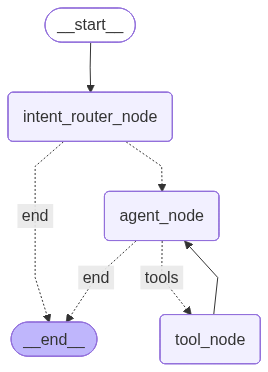

In [10]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
initial_state = {
    "messages": [{"role": "user", "content": "Can I get a tablet for my kid, a watch for me a laptop for my wife and a waterproof speaker for our party next week?"}],
    "available_tools": tool_descriptions
}

In [12]:
results = graph.invoke(initial_state)

In [13]:
results

{'messages': [{'role': 'user',
   'content': 'Can I get a tablet for my kid, a watch for me a laptop for my wife and a waterproof speaker for our party next week?'},
  AIMessage(content='I will search for available tablets suitable for kids, watches, laptops for your wife, and waterproof speakers for your party in our inventory. One moment, please.', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'get_formatted_item_context', 'args': {'query': 'tablet for kids', 'top_k': 5}, 'id': 'call_0', 'type': 'tool_call'}, {'name': 'get_formatted_item_context', 'args': {'query': 'watch', 'top_k': 5}, 'id': 'call_1', 'type': 'tool_call'}, {'name': 'get_formatted_item_context', 'args': {'query': 'laptop', 'top_k': 5}, 'id': 'call_2', 'type': 'tool_call'}, {'name': 'get_formatted_item_context', 'args': {'query': 'waterproof speaker', 'top_k': 5}, 'id': 'call_3', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='- ID: B0C3XYD574, rating: 4.4, description: ROWT Ta

In [14]:
print(results["answer"])

Here are some options for the products you requested:

Tablet for Kids:
- ROWT Tablet for Kids: 10 inch screen, 2GB RAM, 32GB storage, Android 11, 6000mAh battery, kid-proof case, parental controls, and eye protection screen.
- COOPERS 7 inch Kids Tablet: 2GB RAM, 32GB storage, Android 11, parental controls, 6 hours battery life.
- Fullant Kids Tablet 7 inch: Android 12, 32GB, expandable storage, shockproof case, parental controls.

Watch for You:
- Blackview Smart Watch for Women: 24 sports modes, heart rate monitor, blood oxygen, IP68 waterproof, 9-15 days battery life.
- Gifts for Men Fitness Tracker Smart Watch: Heart rate, blood pressure, multiple fitness modes, smart notifications.
- BJNAAL Smart Watch: IP68 waterproof, blood pressure/sleep monitor, 25 sports modes, 7 days battery life.

Laptop for Your Wife:
- jumper Laptop: 16" FHD IPS display, Intel Celeron Quad Core, 4GB RAM, 128GB storage, Windows 11.
- Nulaxy 360 Rotating Laptop Stand and DEOJOY Laptop Desk available as acc

In [15]:
initial_state = {
    "messages": [{"role": "user", "content": "Can you tell me the weather today?"}],
    "available_tools": tool_descriptions
}

In [16]:
results = graph.invoke(initial_state)

In [17]:
results

{'messages': [{'role': 'user',
   'content': 'Can you tell me the weather today?'}],
 'question_relevant': False,
 'answer': 'The question about the weather today is not related to products, inventory, or purchasing. I cannot provide information on the weather.',
 'available_tools': [{'name': 'get_formatted_item_context',
   'description': 'Get the top k context, each representing an inventory item for a given query.',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'description': 'The query to get the top k context for'},
     'top_k': {'type': 'integer',
      'description': 'The number of context chunks to retrieve, works best with 5 or more',
      'default': 5}},
    'required': ['query']},
   'returns': {'type': 'string',
    'description': 'A string of the top k context chunks with IDs and average ratings prepending each chunk, each representing an inventory item for a given query.'}}],
 'references': []}